##LSTM 모델

In [ ]:
import os
import yfinance as yf
import pandas as pd
import numpy as np

# ==========================================
# 1. 10년치 기초 데이터 다운로드 (2015.01 ~ 2025.01)
# ==========================================
def get_raw_data(ticker):
    print(f"[{ticker}] 10년치 데이터 다운로드 중...")
    df = yf.download(ticker, start="2015-01-01", end="2025-01-01", progress=False)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA60'] = df['Close'].rolling(window=60).mean()
    df['Future_Return'] = df['Close'].shift(-20) / df['Close'] - 1

    df.dropna(inplace=True)
    return df

df_spy = get_raw_data('SPY')
df_qqq = get_raw_data('QQQ')

# ==========================================
# 2. 슬라이딩 윈도우 생성 및 완벽한 시계열 분할
# ==========================================
def create_sequences(df, window_size=60):
    X, returns = [], []
    data = df[['Open', 'High', 'Low', 'Close', 'Volume', 'MA20', 'MA60']].values
    ret_data = df['Future_Return'].values
    for i in range(len(data) - window_size):
        X.append(data[i : i+window_size])
        returns.append(ret_data[i + window_size - 1])
    return np.array(X), np.array(returns)

X_spy, ret_spy = create_sequences(df_spy)
X_qqq, ret_qqq = create_sequences(df_qqq)

# 🌟 각 종목별로 정확히 80%(Train) / 20%(Test) 분할
split_spy = int(len(X_spy) * 0.8)
split_qqq = int(len(X_qqq) * 0.8)

# Train Set (과거 8년) 통합
X_train_base = np.concatenate((X_spy[:split_spy], X_qqq[:split_qqq]), axis=0)
ret_train_base = np.concatenate((ret_spy[:split_spy], ret_qqq[:split_qqq]), axis=0)

# Test Set (최근 2년) 통합
X_test_base = np.concatenate((X_spy[split_spy:], X_qqq[split_qqq:]), axis=0)
ret_test_base = np.concatenate((ret_spy[split_spy:], ret_qqq[split_qqq:]), axis=0)

print(f"\n✅ 기초 분할 완료! (데이터 누수 완벽 차단)")
print(f"Train Base (8년): {X_train_base.shape[0]}개")
print(f"Test Base (2년): {X_test_base.shape[0]}개")

[SPY] 10년치 데이터 다운로드 중...


/tmp/ipython-input-438/2737725450.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2015-01-01", end="2025-01-01", progress=False)


[QQQ] 10년치 데이터 다운로드 중...


/tmp/ipython-input-438/2737725450.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2015-01-01", end="2025-01-01", progress=False)



✅ 기초 분할 완료! (데이터 누수 완벽 차단)
Train Base (8년): 3802개
Test Base (2년): 952개


In [ ]:
# ==========================================
# 전략 1: 노이즈 버리기 (상위 30% vs 하위 30%)
# ==========================================
import os
import numpy as np

os.makedirs('./dataset_strategy_1', exist_ok=True)

# 🌟 기준선(Threshold)은 반드시 Train 데이터에서만 구합니다 (Data Leakage 방지)
p30 = np.percentile(ret_train_base, 30)
p70 = np.percentile(ret_train_base, 70)

# Train 데이터 필터링
idx_tr_c0 = np.where(ret_train_base <= p30)[0]
idx_tr_c1 = np.where(ret_train_base >= p70)[0]
X_s1_tr = np.concatenate((X_train_base[idx_tr_c0], X_train_base[idx_tr_c1]), axis=0)
Y_s1_tr = np.concatenate((np.zeros(len(idx_tr_c0)), np.ones(len(idx_tr_c1))), axis=0)

# Test 데이터 필터링
idx_te_c0 = np.where(ret_test_base <= p30)[0]
idx_te_c1 = np.where(ret_test_base >= p70)[0]
X_s1_te = np.concatenate((X_test_base[idx_te_c0], X_test_base[idx_te_c1]), axis=0)
Y_s1_te = np.concatenate((np.zeros(len(idx_te_c0)), np.ones(len(idx_te_c1))), axis=0)

# 최종 결합 (LSTM 코드에서 80%로 자르면 다시 정확히 Train/Test로 나뉩니다)
X_s1 = np.concatenate((X_s1_tr, X_s1_te), axis=0)
Y_s1 = np.concatenate((Y_s1_tr, Y_s1_te), axis=0)

np.save('./dataset_strategy_1/X_data.npy', X_s1)
np.save('./dataset_strategy_1/Y_data.npy', Y_s1)

print(f"🎯 [Strategy 1] 완료!")
print(f"기준선: {p30*100:.2f}%(하락) / {p70*100:.2f}%(상승)")
print(f"최종 데이터 개수: {len(X_s1)}개 저장됨.")

🎯 [Strategy 1] 완료!
기준선: -0.44%(하락) / 3.62%(상승)
최종 데이터 개수: 2823개 저장됨.


In [ ]:
# ==========================================
# 전략 2: 상대적 3분위수 (하락 33% / 횡보 33% / 상승 33%)
# ==========================================
import os
import numpy as np

os.makedirs('./dataset_strategy_2', exist_ok=True)

# 🌟 Train 데이터 기준으로 3등분(33.3%, 66.7%) 선 도출
p33 = np.percentile(ret_train_base, 33.33)
p66 = np.percentile(ret_train_base, 66.67)

# Train/Test를 원래 순서대로 결합
X_s2 = np.concatenate((X_train_base, X_test_base), axis=0)
ret_all_s2 = np.concatenate((ret_train_base, ret_test_base), axis=0)

# 정답지 생성 (0, 1, 2)
Y_s2 = np.zeros_like(ret_all_s2)
Y_s2[(ret_all_s2 > p33) & (ret_all_s2 <= p66)] = 1
Y_s2[ret_all_s2 > p66] = 2

np.save('./dataset_strategy_2/X_data.npy', X_s2)
np.save('./dataset_strategy_2/Y_data.npy', Y_s2)

print(f"🎯 [Strategy 2] 완료!")
print(f"기준선: 하위 33%({p33*100:.2f}%) / 상위 33%({p66*100:.2f}%)")
print(f"최종 데이터 개수: {len(X_s2)}개 저장됨.")

🎯 [Strategy 2] 완료!
기준선: 하위 33%(0.00%) / 상위 33%(3.32%)
최종 데이터 개수: 4754개 저장됨.


In [ ]:
# ==========================================
# 전략 3: 중앙값 기준 (상위 50% vs 하위 50%)
# ==========================================
import os
import numpy as np

os.makedirs('./dataset_strategy_3', exist_ok=True)

# 🌟 Train 데이터 기준으로 중간값(Median) 도출
median_ret = np.median(ret_train_base)

# Train/Test 원래 순서대로 결합
X_s3 = np.concatenate((X_train_base, X_test_base), axis=0)
ret_all_s3 = np.concatenate((ret_train_base, ret_test_base), axis=0)

# 중간값 기준으로 이진 분류
Y_s3 = np.where(ret_all_s3 >= median_ret, 1, 0)

np.save('./dataset_strategy_3/X_data.npy', X_s3)
np.save('./dataset_strategy_3/Y_data.npy', Y_s3)

print(f"🎯 [Strategy 3] 완료!")
print(f"기준선: 중앙값({median_ret*100:.2f}%)")
print(f"최종 데이터 개수: {len(X_s3)}개 저장됨.")

🎯 [Strategy 3] 완료!
기준선: 중앙값(1.74%)
최종 데이터 개수: 4754개 저장됨.


---


🚀 [Strategy 1 (Extreme 2-Class)] 학습 시작 (Classes: 2)
Epoch 01/40 | Train Acc: 0.5416 | Test Acc: 0.4124
Epoch 10/40 | Train Acc: 0.5872 | Test Acc: 0.5327
Epoch 20/40 | Train Acc: 0.6076 | Test Acc: 0.5327
Epoch 30/40 | Train Acc: 0.7259 | Test Acc: 0.4938
Epoch 40/40 | Train Acc: 0.7755 | Test Acc: 0.4991

🎯 [Strategy 1 (Extreme 2-Class)] 최종 Test Set 예측 분포 진단
  - Class 0: 228개 예측 (40.4%)
  - Class 1: 337개 예측 (59.6%)
  ✅ 정상: 붕괴 현상 없이 여러 클래스를 고르게 예측하고 있습니다.

🚀 [Strategy 2 (Tertile 3-Class)] 학습 시작 (Classes: 3)
Epoch 01/40 | Train Acc: 0.4042 | Test Acc: 0.3859
Epoch 10/40 | Train Acc: 0.4473 | Test Acc: 0.3954
Epoch 20/40 | Train Acc: 0.4967 | Test Acc: 0.2965
Epoch 30/40 | Train Acc: 0.5588 | Test Acc: 0.2986
Epoch 40/40 | Train Acc: 0.6584 | Test Acc: 0.3091

🎯 [Strategy 2 (Tertile 3-Class)] 최종 Test Set 예측 분포 진단
  - Class 0: 368개 예측 (38.7%)
  - Class 1: 295개 예측 (31.0%)
  - Class 2: 288개 예측 (30.3%)
  ✅ 정상: 붕괴 현상 없이 여러 클래스를 고르게 예측하고 있습니다.

🚀 [Strategy 3 (Median 2-Class)] 학습 시작 (Classes: 

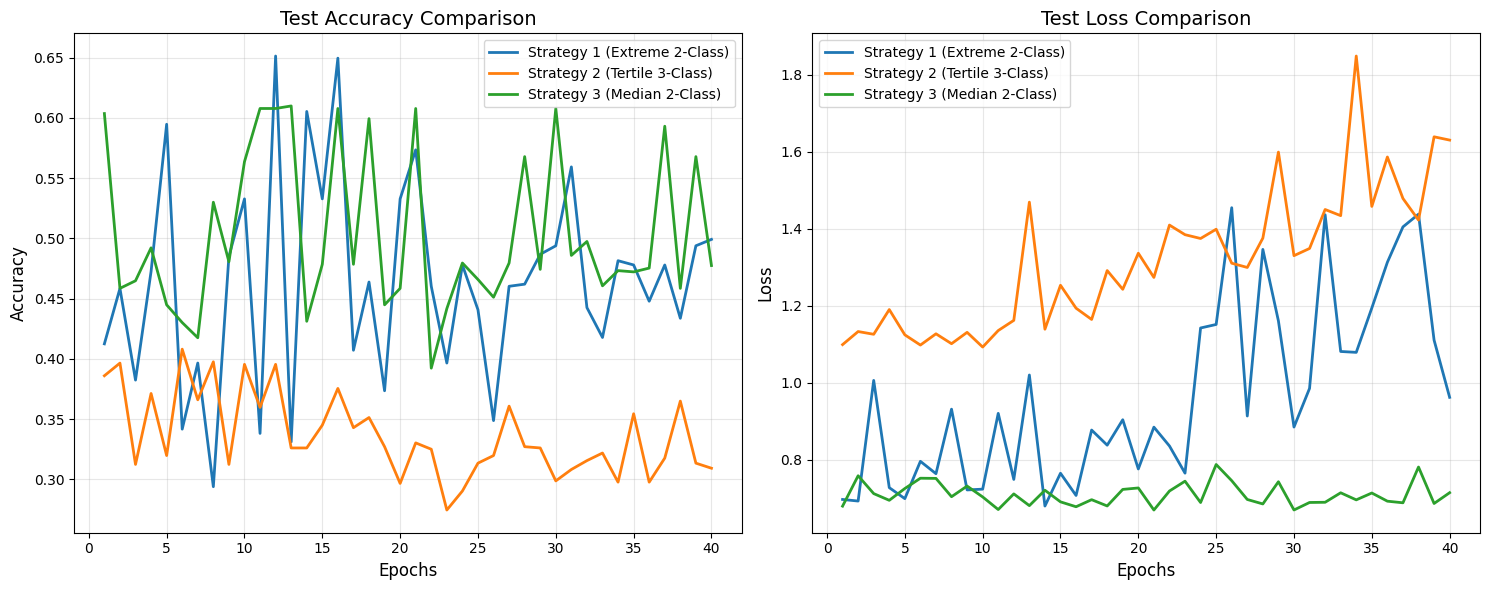

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# ==========================================
# 1. Random Seed & 공통 Hyperparameter 세팅
# ==========================================
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.1
LEARNING_RATE = 0.001
EPOCHS = 40
BATCH_SIZE = 64
INPUT_SIZE = 7  # (Open, High, Low, Close, Volume, MA20, MA60)

# ==========================================
# 2. Custom Dataset (가격/거래량 분리 정규화)
# ==========================================
class AdvancedLSTMDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        x_seq = self.x[idx].clone()

        # 가격 관련 지표(0,1,2,3,5,6) 묶어서 정규화
        price_indices = [0, 1, 2, 3, 5, 6]
        prices = x_seq[:, price_indices]
        p_min, p_max = prices.min(), prices.max()
        x_seq[:, price_indices] = (prices - p_min) / (p_max - p_min + 1e-8)

        # 거래량(4) 단독 정규화
        vol = x_seq[:, 4]
        v_min, v_max = vol.min(), vol.max()
        x_seq[:, 4] = (vol - v_min) / (v_max - v_min + 1e-8)

        return x_seq, self.y[idx]

# ==========================================
# 3. Model Definition
# ==========================================
class StockLSTM(nn.Module):
    def __init__(self, out_dim):
        super(StockLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=INPUT_SIZE,
            hidden_size=HIDDEN_DIM,
            num_layers=NUM_LAYERS,
            batch_first=True,
            dropout=DROPOUT
        )
        self.bn = nn.BatchNorm1d(HIDDEN_DIM)
        self.dropout = nn.Dropout(DROPOUT)
        self.fc = nn.Linear(HIDDEN_DIM, out_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :]
        out = self.bn(last_out)
        out = self.dropout(out)
        out = self.fc(out)
        return out

# ==========================================
# 4. Training Pipeline Function (붕괴 진단 기능 추가 🌟)
# ==========================================
def train_evaluate_strategy(strategy_name, data_dir, out_dim):
    print(f"\n{'='*55}")
    print(f"🚀 [{strategy_name}] 학습 시작 (Classes: {out_dim})")
    print(f"{'='*55}")

    X_data = np.load(f'{data_dir}/X_data.npy')
    Y_data = np.load(f'{data_dir}/Y_data.npy')

    split_idx = int(len(X_data) * 0.8)
    X_train, X_test = X_data[:split_idx], X_data[split_idx:]
    Y_train, Y_test = Y_data[:split_idx], Y_data[split_idx:]

    train_dataset = AdvancedLSTMDataset(X_train, Y_train)
    test_dataset = AdvancedLSTMDataset(X_test, Y_test)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = StockLSTM(out_dim).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(EPOCHS):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += torch.sum(preds == labels.data)
            train_total += inputs.size(0)

        model.eval()
        test_loss, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                test_correct += torch.sum(preds == labels.data)
                test_total += inputs.size(0)

        history['train_loss'].append(train_loss / train_total)
        history['test_loss'].append(test_loss / test_total)
        history['train_acc'].append((train_correct.double() / train_total).item())
        history['test_acc'].append((test_correct.double() / test_total).item())

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Acc: {history['train_acc'][-1]:.4f} | Test Acc: {history['test_acc'][-1]:.4f}")

    # 🌟 [추가된 기능] 학습 종료 후 Test Set 예측 분포 확인 (다중 클래스 붕괴 진단) 🌟
    model.eval()
    all_preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())

    all_preds = np.array(all_preds)
    unique_pred, counts_pred = np.unique(all_preds, return_counts=True)

    print(f"\n🎯 [{strategy_name}] 최종 Test Set 예측 분포 진단")
    total_preds = len(all_preds)
    is_collapsed = False

    for u, c in zip(unique_pred, counts_pred):
        ratio = (c / total_preds) * 100
        print(f"  - Class {u}: {c}개 예측 ({ratio:.1f}%)")
        if ratio >= 90.0:  # 특정 클래스에 90% 이상 쏠리면 붕괴로 판정
            is_collapsed = True

    if is_collapsed:
        print("  ⚠️ 🚨 경고: 특정 클래스에 예측이 집중되는 다중 클래스 붕괴 현상이 발생했습니다!")
    else:
        print("  ✅ 정상: 붕괴 현상 없이 여러 클래스를 고르게 예측하고 있습니다.")

    return history

# ==========================================
# 5. Execute Experiments & Plot Comparison
# ==========================================
strategies = [
    {"name": "Strategy 1 (Extreme 2-Class)", "dir": "./dataset_strategy_1", "out_dim": 2},
    {"name": "Strategy 2 (Tertile 3-Class)", "dir": "./dataset_strategy_2", "out_dim": 3},
    {"name": "Strategy 3 (Median 2-Class)", "dir": "./dataset_strategy_3", "out_dim": 2}
]

all_histories = {}

for strat in strategies:
    if os.path.exists(strat["dir"]):
        hist = train_evaluate_strategy(strat["name"], strat["dir"], strat["out_dim"])
        all_histories[strat["name"]] = hist
    else:
        print(f"[경고] {strat['dir']} 폴더를 찾을 수 없습니다. 데이터셋을 먼저 생성해주세요.")

# 결과 시각화
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
for name, hist in all_histories.items():
    plt.plot(range(1, EPOCHS + 1), hist['test_acc'], label=name, linewidth=2)
plt.title('Test Accuracy Comparison', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for name, hist in all_histories.items():
    plt.plot(range(1, EPOCHS + 1), hist['test_loss'], label=name, linewidth=2)
plt.title('Test Loss Comparison', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##LSTM 모델 튜닝

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Colab 셀에 이렇게 입력하여 로컬로 복사 후 압축을 푸는 것을 권장합니다.
!cp /content/drive/MyDrive/YAI/17기/'CV 3팀'/'Toy Project'/'dataset_strategy_2_10년.zip' /content/
!unzip -q /content/dataset_strategy_2_10년.zip -d /content/

###테스트

In [ ]:
import os
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import itertools

# ==========================================
# 0. Random Seed & 기본 설정
# ==========================================
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
INPUT_SIZE = 7
OUT_DIM = 3 # 전략 2는 3-Class
STRATEGY_DIR = './dataset_strategy_2_10years'

# ==========================================
# 1. 10년치 기초 데이터 및 전략 2 데이터셋 생성 (1회성)
# ==========================================
print("📦 1. 10년치(2015.01 ~ 2025.01) 데이터셋 구축 시작...")
def get_raw_data(ticker):
    df = yf.download(ticker, start="2015-01-01", end="2025-01-01", progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df['MA20'] = df['Close'].rolling(window=20).mean()
    df['MA60'] = df['Close'].rolling(window=60).mean()
    df['Future_Return'] = df['Close'].shift(-20) / df['Close'] - 1
    df.dropna(inplace=True)
    return df

def create_sequences(df, window_size=60):
    X, returns = [], []
    data = df[['Open', 'High', 'Low', 'Close', 'Volume', 'MA20', 'MA60']].values
    ret_data = df['Future_Return'].values
    for i in range(len(data) - window_size):
        X.append(data[i : i+window_size])
        returns.append(ret_data[i + window_size - 1])
    return np.array(X), np.array(returns)

if not os.path.exists(os.path.join(STRATEGY_DIR, 'X_data.npy')):
    df_spy, df_qqq = get_raw_data('SPY'), get_raw_data('QQQ')
    X_spy, ret_spy = create_sequences(df_spy)
    X_qqq, ret_qqq = create_sequences(df_qqq)

    # 8년(Train) / 2년(Test) 분할 (80:20)
    split_spy, split_qqq = int(len(X_spy) * 0.8), int(len(X_qqq) * 0.8)

    X_train_base = np.concatenate((X_spy[:split_spy], X_qqq[:split_qqq]), axis=0)
    ret_train_base = np.concatenate((ret_spy[:split_spy], ret_qqq[:split_qqq]), axis=0)
    X_test_base = np.concatenate((X_spy[split_spy:], X_qqq[split_qqq:]), axis=0)
    ret_test_base = np.concatenate((ret_spy[split_spy:], ret_qqq[split_qqq:]), axis=0)

    # 전략 2 (Train 3분위수 도출)
    p33 = np.percentile(ret_train_base, 33.33)
    p66 = np.percentile(ret_train_base, 66.67)

    X_all = np.concatenate((X_train_base, X_test_base), axis=0)
    ret_all = np.concatenate((ret_train_base, ret_test_base), axis=0)

    Y_s2 = np.zeros_like(ret_all)
    Y_s2[(ret_all > p33) & (ret_all <= p66)] = 1
    Y_s2[ret_all > p66] = 2

    os.makedirs(STRATEGY_DIR, exist_ok=True)
    np.save(f'{STRATEGY_DIR}/X_data.npy', X_all)
    np.save(f'{STRATEGY_DIR}/Y_data.npy', Y_s2)
    print(f"✅ 10년치 전략 2 데이터 생성 완료! (총 {len(X_all)}개)")
else:
    print(f"✅ 10년치 전략 2 데이터가 이미 존재합니다. 바로 학습을 시작합니다.")

# ==========================================
# 2. Dataset & Model Definition
# ==========================================
class AdvancedLSTMDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.x)
    def __getitem__(self, idx):
        x_seq = self.x[idx].clone()
        price_indices = [0, 1, 2, 3, 5, 6]
        prices = x_seq[:, price_indices]
        p_min, p_max = prices.min(), prices.max()
        x_seq[:, price_indices] = (prices - p_min) / (p_max - p_min + 1e-8)

        vol = x_seq[:, 4]
        v_min, v_max = vol.min(), vol.max()
        x_seq[:, 4] = (vol - v_min) / (v_max - v_min + 1e-8)
        return x_seq, self.y[idx]

class StockLSTM(nn.Module):
    def __init__(self, hidden_dim, dropout, num_layers=2):
        super(StockLSTM, self).__init__()
        self.lstm = nn.LSTM(INPUT_SIZE, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, OUT_DIM)
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.bn(lstm_out[:, -1, :])
        out = self.dropout(out)
        return self.fc(out)

# ==========================================
# 3. Grid Search Function
# ==========================================
def run_experiment(hidden_dim, lr, dropout, batch_size, epochs=30):
    # 데이터 로딩
    X_data = np.load(f'{STRATEGY_DIR}/X_data.npy')
    Y_data = np.load(f'{STRATEGY_DIR}/Y_data.npy')
    split_idx = int(len(X_data) * 0.8)

    train_loader = DataLoader(AdvancedLSTMDataset(X_data[:split_idx], Y_data[:split_idx]), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(AdvancedLSTMDataset(X_data[split_idx:], Y_data[split_idx:]), batch_size=batch_size, shuffle=False)

    model = StockLSTM(hidden_dim, dropout).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_test_acc = 0.0

    for epoch in range(epochs):
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs.to(device))
            loss = criterion(outputs, labels.to(device))
            loss.backward()
            optimizer.step()

        model.eval()
        test_correct, test_total = 0, 0
        all_preds = []
        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = model(inputs.to(device))
                _, preds = torch.max(outputs, 1)
                test_correct += torch.sum(preds == labels.to(device)).item()
                test_total += inputs.size(0)
                all_preds.extend(preds.cpu().numpy())

        epoch_acc = test_correct / test_total
        if epoch_acc > best_test_acc:
            best_test_acc = epoch_acc

    # 다중 클래스 붕괴 확인 (마지막 Epoch 기준)
    unique_pred, counts_pred = np.unique(all_preds, return_counts=True)
    is_collapsed = any((c / test_total) >= 0.90 for c in counts_pred)

    return best_test_acc, is_collapsed

# ==========================================
# 4. 본격적인 파라미터 튜닝 실행
# ==========================================
# 🌟 탐색할 파라미터 공간 (필요에 따라 자유롭게 변경하세요!)
search_space = {
    'hidden_dim': [64, 128],
    'lr': [0.001, 0.0005],
    'dropout': [0.1, 0.3],
    'batch_size': [32, 64]
}

# 모든 조합 생성
keys, values = zip(*search_space.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"\n🚀 총 {len(experiments)}개의 파라미터 조합 탐색을 시작합니다...\n")

results = []
for i, exp in enumerate(experiments):
    print(f"[{i+1}/{len(experiments)}] 실험 중... (Hidden:{exp['hidden_dim']}, LR:{exp['lr']}, Drop:{exp['dropout']}, Batch:{exp['batch_size']})")

    # 🌟 실험 속도를 위해 epochs는 30으로 고정했습니다.
    best_acc, is_collapsed = run_experiment(**exp, epochs=30)

    exp['best_acc'] = best_acc
    exp['collapsed'] = "🚨 붕괴" if is_collapsed else "✅ 정상"
    results.append(exp)
    print(f"  -> 결과: Test Acc {best_acc:.4f} ({exp['collapsed']})")

# 결과 정렬 및 출력
results.sort(key=lambda x: x['best_acc'], reverse=True)

print("\n🏆 최적의 하이퍼파라미터 Top 3 🏆")
print("-" * 65)
for i in range(3):
    r = results[i]
    print(f"Rank {i+1}: Acc {r['best_acc']:.4f} | Hidden: {r['hidden_dim']}, LR: {r['lr']}, Drop: {r['dropout']}, Batch: {r['batch_size']} | 상태: {r['collapsed']}")
print("-" * 65)

📦 1. 10년치(2015.01 ~ 2025.01) 데이터셋 구축 시작...
✅ 10년치 전략 2 데이터 생성 완료! (총 4754개)

🚀 총 16개의 파라미터 조합 탐색을 시작합니다...

[1/16] 실험 중... (Hidden:64, LR:0.001, Drop:0.1, Batch:32)


/tmp/ipython-input-708/462464821.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2015-01-01", end="2025-01-01", progress=False)
/tmp/ipython-input-708/462464821.py:31: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2015-01-01", end="2025-01-01", progress=False)


  -> 결과: Test Acc 0.4280 (✅ 정상)
[2/16] 실험 중... (Hidden:64, LR:0.001, Drop:0.1, Batch:64)
  -> 결과: Test Acc 0.4385 (✅ 정상)
[3/16] 실험 중... (Hidden:64, LR:0.001, Drop:0.3, Batch:32)
  -> 결과: Test Acc 0.4080 (✅ 정상)
[4/16] 실험 중... (Hidden:64, LR:0.001, Drop:0.3, Batch:64)
  -> 결과: Test Acc 0.4217 (✅ 정상)
[5/16] 실험 중... (Hidden:64, LR:0.0005, Drop:0.1, Batch:32)
  -> 결과: Test Acc 0.4217 (✅ 정상)
[6/16] 실험 중... (Hidden:64, LR:0.0005, Drop:0.1, Batch:64)
  -> 결과: Test Acc 0.4196 (✅ 정상)
[7/16] 실험 중... (Hidden:64, LR:0.0005, Drop:0.3, Batch:32)
  -> 결과: Test Acc 0.4206 (✅ 정상)
[8/16] 실험 중... (Hidden:64, LR:0.0005, Drop:0.3, Batch:64)
  -> 결과: Test Acc 0.4248 (✅ 정상)
[9/16] 실험 중... (Hidden:128, LR:0.001, Drop:0.1, Batch:32)
  -> 결과: Test Acc 0.4374 (✅ 정상)
[10/16] 실험 중... (Hidden:128, LR:0.001, Drop:0.1, Batch:64)
  -> 결과: Test Acc 0.4175 (✅ 정상)
[11/16] 실험 중... (Hidden:128, LR:0.001, Drop:0.3, Batch:32)
  -> 결과: Test Acc 0.4448 (✅ 정상)
[12/16] 실험 중... (Hidden:128, LR:0.001, Drop:0.3, Batch:64)
  -> 결과: T

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import itertools

# ==========================================
# 0. Random Seed & 기본 설정
# ==========================================
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
INPUT_SIZE = 7
OUT_DIM = 3 # 전략 2 (3-Class)
#STRATEGY_DIR = './drive/MyDrive/YAI/17기/CV 3팀/Toy Project/dataset_strategy_2_10년' # 이전 단계에서 만든 10년치 데이터 폴더
STRATEGY_DIR = './drive/MyDrive/YAI/17기/CV 3팀/Toy Project/dataset_strategy_2_10년'

# ==========================================
# 1. Dataset & Model Definition
# ==========================================
class AdvancedLSTMDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.x)
    def __getitem__(self, idx):
        x_seq = self.x[idx].clone()
        price_indices = [0, 1, 2, 3, 5, 6]
        prices = x_seq[:, price_indices]
        p_min, p_max = prices.min(), prices.max()
        x_seq[:, price_indices] = (prices - p_min) / (p_max - p_min + 1e-8)

        vol = x_seq[:, 4]
        v_min, v_max = vol.min(), vol.max()
        x_seq[:, 4] = (vol - v_min) / (v_max - v_min + 1e-8)
        return x_seq, self.y[idx]

class StockLSTM(nn.Module):
    def __init__(self, hidden_dim, dropout, num_layers):
        super(StockLSTM, self).__init__()
        self.lstm = nn.LSTM(INPUT_SIZE, hidden_dim, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, OUT_DIM)
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.bn(lstm_out[:, -1, :])
        out = self.dropout(out)
        return self.fc(out)

# ==========================================
# 2. Training & Evaluation Tracking Function
# ==========================================
def train_and_track(hidden_dim, num_layers, lr, dropout, batch_size, weight_decay, epochs):
    X_data = np.load(f'{STRATEGY_DIR}/X_data.npy')
    Y_data = np.load(f'{STRATEGY_DIR}/Y_data.npy')
    split_idx = int(len(X_data) * 0.8)

    train_loader = DataLoader(AdvancedLSTMDataset(X_data[:split_idx], Y_data[:split_idx]), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(AdvancedLSTMDataset(X_data[split_idx:], Y_data[split_idx:]), batch_size=batch_size, shuffle=False)

    model = StockLSTM(hidden_dim, dropout, num_layers).to(device)
    criterion = nn.CrossEntropyLoss()
    # 🌟 L2 Norm(Weight Decay) 적용
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # 기록장(Tracker) 초기화
    best_metrics = {
        'train_loss': float('inf'), 'train_loss_ep': -1,
        'test_loss': float('inf'),  'test_loss_ep': -1,
        'train_acc': 0.0,           'train_acc_ep': -1,
        'test_acc': 0.0,            'test_acc_ep': -1
    }

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += torch.sum(preds == labels.data).item()
            train_total += inputs.size(0)

        epoch_train_loss = train_loss_sum / train_total
        epoch_train_acc = train_correct / train_total

        # --- Evaluate ---
        model.eval()
        test_loss_sum, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss_sum += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                test_correct += torch.sum(preds == labels.data).item()
                test_total += inputs.size(0)

        epoch_test_loss = test_loss_sum / test_total
        epoch_test_acc = test_correct / test_total

        # 🌟 최고/최저 기록 갱신 및 해당 Epoch 저장
        current_ep = epoch + 1
        if epoch_train_loss < best_metrics['train_loss']:
            best_metrics['train_loss'], best_metrics['train_loss_ep'] = epoch_train_loss, current_ep
        if epoch_test_loss < best_metrics['test_loss']:
            best_metrics['test_loss'], best_metrics['test_loss_ep'] = epoch_test_loss, current_ep

        if epoch_train_acc > best_metrics['train_acc']:
            best_metrics['train_acc'], best_metrics['train_acc_ep'] = epoch_train_acc, current_ep
        if epoch_test_acc > best_metrics['test_acc']:
            best_metrics['test_acc'], best_metrics['test_acc_ep'] = epoch_test_acc, current_ep

    return best_metrics

# ==========================================
# 3. Grid Search 실행 (시트 양식에 맞춤)
# ==========================================
# 🌟 탐색할 파라미터 공간 (이 값들을 변경하여 실험을 추가하세요!)
search_space = {
    'epochs': [40],                 # 공통 1 (시트 기준 고정값)
    'batch_size': [32, 64],         # 공통 2
    'dropout': [0.1, 0.3],          # 공통 3
    'lr': [0.001, 0.0005],          # 공통 4
    'weight_decay': [1e-5, 0.0],    # 공통 5 (L2 Norm)
    'hidden_dim': [64, 128],        # LSTM 전용 1
    'num_layers': [1, 2]            # LSTM 전용 2
}

keys, values = zip(*search_space.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

print(f"\n🚀 총 {len(experiments)}개의 파라미터 조합 탐색을 시작합니다...\n")

results_list = []
for i, exp in enumerate(experiments):
    print(f"[{i+1}/{len(experiments)}] 실험 중... (Batch:{exp['batch_size']}, LR:{exp['lr']}, Drop:{exp['dropout']}, L2:{exp['weight_decay']}, Hidden:{exp['hidden_dim']}, Layers:{exp['num_layers']})")

    best_metrics = train_and_track(**exp)

    # 시트 양식에 맞게 결과 딕셔너리 구성
    result_row = {
        '실험 번호': i + 1,
        'Epoch': exp['epochs'],
        'Batch Size': exp['batch_size'],
        'Dropout Rate': exp['dropout'],
        'Learning Rate': exp['lr'],
        'L2 Norm': exp['weight_decay'],
        'Hidden Dim': exp['hidden_dim'],
        'Num Layers': exp['num_layers'],

        # 모델의 베스트 기록과 그때의 Epoch
        'Train Loss (Best)': f"{best_metrics['train_loss']:.4f} (ep:{best_metrics['train_loss_ep']})",
        'Test Loss (Best)': f"{best_metrics['test_loss']:.4f} (ep:{best_metrics['test_loss_ep']})",
        'Train Acc (Best)': f"{best_metrics['train_acc']:.4f} (ep:{best_metrics['train_acc_ep']})",
        'Test Acc (Best)': f"{best_metrics['test_acc']:.4f} (ep:{best_metrics['test_acc_ep']})"
    }
    results_list.append(result_row)

# ==========================================
# 4. 결과를 DataFrame으로 만들고 CSV로 자동 저장
# ==========================================
df_results = pd.DataFrame(results_list)

# 화면에 예쁘게 출력
print("\n🏆 실험 결과 요약 (Test Acc 기준 내림차순) 🏆")
df_sorted = df_results.sort_values(by='Test Acc (Best)', ascending=False)
print(df_sorted[['실험 번호', 'Hidden Dim', 'Num Layers', 'LR', 'Test Acc (Best)', 'Test Loss (Best)']].head(5).to_string(index=False))

# CSV 파일로 저장
csv_filename = 'lstm_experiment_results.csv'
df_results.to_csv(csv_filename, index=False, encoding='utf-8-sig')
print(f"\n✅ 전체 실험 결과가 '{csv_filename}' 파일로 저장되었습니다. 이 파일을 다운로드하여 엑셀 시트에 복사 붙여넣기 하세요!")


🚀 총 64개의 파라미터 조합 탐색을 시작합니다...

[1/64] 실험 중... (Batch:32, LR:0.001, Drop:0.1, L2:1e-05, Hidden:64, Layers:1)
[2/64] 실험 중... (Batch:32, LR:0.001, Drop:0.1, L2:1e-05, Hidden:64, Layers:2)
[3/64] 실험 중... (Batch:32, LR:0.001, Drop:0.1, L2:1e-05, Hidden:128, Layers:1)
[4/64] 실험 중... (Batch:32, LR:0.001, Drop:0.1, L2:1e-05, Hidden:128, Layers:2)
[5/64] 실험 중... (Batch:32, LR:0.001, Drop:0.1, L2:0.0, Hidden:64, Layers:1)
[6/64] 실험 중... (Batch:32, LR:0.001, Drop:0.1, L2:0.0, Hidden:64, Layers:2)
[7/64] 실험 중... (Batch:32, LR:0.001, Drop:0.1, L2:0.0, Hidden:128, Layers:1)
[8/64] 실험 중... (Batch:32, LR:0.001, Drop:0.1, L2:0.0, Hidden:128, Layers:2)
[9/64] 실험 중... (Batch:32, LR:0.0005, Drop:0.1, L2:1e-05, Hidden:64, Layers:1)
[10/64] 실험 중... (Batch:32, LR:0.0005, Drop:0.1, L2:1e-05, Hidden:64, Layers:2)
[11/64] 실험 중... (Batch:32, LR:0.0005, Drop:0.1, L2:1e-05, Hidden:128, Layers:1)
[12/64] 실험 중... (Batch:32, LR:0.0005, Drop:0.1, L2:1e-05, Hidden:128, Layers:2)


###로그 기능 추가

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import itertools
import matplotlib
matplotlib.use('Agg') # 화면 출력 없이 백그라운드에서 그래프 파일 생성
import matplotlib.pyplot as plt

# ==========================================
# 0. 초기 설정 및 폴더 준비
# ==========================================
seed = 123
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
INPUT_SIZE = 7
OUT_DIM = 3
STRATEGY_DIR = './dataset_strategy_2'

# 🌟 그래프를 저장할 폴더 생성
PLOT_DIR = './lstm_plots'
os.makedirs(PLOT_DIR, exist_ok=True)

# ==========================================
# 1. Dataset & Model Definition (이전과 동일)
# ==========================================
class AdvancedLSTMDataset(Dataset):
    def __init__(self, x, y):
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.x)
    def __getitem__(self, idx):
        x_seq = self.x[idx].clone()
        price_indices = [0, 1, 2, 3, 5, 6]
        prices = x_seq[:, price_indices]
        p_min, p_max = prices.min(), prices.max()
        x_seq[:, price_indices] = (prices - p_min) / (p_max - p_min + 1e-8)
        vol = x_seq[:, 4]
        v_min, v_max = vol.min(), vol.max()
        x_seq[:, 4] = (vol - v_min) / (v_max - v_min + 1e-8)
        return x_seq, self.y[idx]

class StockLSTM(nn.Module):
    def __init__(self, hidden_dim, dropout, num_layers):
        super(StockLSTM, self).__init__()
        self.lstm = nn.LSTM(INPUT_SIZE, hidden_dim, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.bn = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, OUT_DIM)
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.bn(lstm_out[:, -1, :])
        out = self.dropout(out)
        return self.fc(out)

# ==========================================
# 2. Training Function (상세 로깅 및 그래프 생성 추가)
# ==========================================
def train_and_track_lstm(exp_id, hidden_dim, num_layers, lr, dropout, batch_size, weight_decay, epochs):
    X_data = np.load(f'{STRATEGY_DIR}/X_data.npy')
    Y_data = np.load(f'{STRATEGY_DIR}/Y_data.npy')
    split_idx = int(len(X_data) * 0.8)

    train_loader = DataLoader(AdvancedLSTMDataset(X_data[:split_idx], Y_data[:split_idx]), batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(AdvancedLSTMDataset(X_data[split_idx:], Y_data[split_idx:]), batch_size=batch_size, shuffle=False)

    model = StockLSTM(hidden_dim, dropout, num_layers).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_metrics = {
        'train_loss': float('inf'), 'train_loss_ep': -1, 'test_loss': float('inf'),  'test_loss_ep': -1,
        'train_acc': 0.0, 'train_acc_ep': -1, 'test_acc': 0.0, 'test_acc_ep': -1
    }

    # 🌟 매 Epoch의 기록을 담을 리스트
    epoch_logs = []

    for epoch in range(epochs):
        model.train()
        train_loss_sum, train_correct, train_total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += torch.sum(preds == labels.data).item()
            train_total += inputs.size(0)

        epoch_train_loss = train_loss_sum / train_total
        epoch_train_acc = train_correct / train_total

        model.eval()
        test_loss_sum, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss_sum += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                test_correct += torch.sum(preds == labels.data).item()
                test_total += inputs.size(0)

        epoch_test_loss = test_loss_sum / test_total
        epoch_test_acc = test_correct / test_total

        current_ep = epoch + 1

        # 🌟 콘솔에 실시간 상세 출력
        print(f"   ↳ [Epoch {current_ep:02d}/{epochs}] Train Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Test Acc: {epoch_test_acc:.4f}")

        # 🌟 상세 로그 리스트에 추가
        epoch_logs.append({
            '실험 번호': exp_id,
            'Epoch': current_ep,
            'Train Loss': epoch_train_loss,
            'Test Loss': epoch_test_loss,
            'Train Acc': epoch_train_acc,
            'Test Acc': epoch_test_acc
        })

        if epoch_train_loss < best_metrics['train_loss']: best_metrics['train_loss'], best_metrics['train_loss_ep'] = epoch_train_loss, current_ep
        if epoch_test_loss < best_metrics['test_loss']: best_metrics['test_loss'], best_metrics['test_loss_ep'] = epoch_test_loss, current_ep
        if epoch_train_acc > best_metrics['train_acc']: best_metrics['train_acc'], best_metrics['train_acc_ep'] = epoch_train_acc, current_ep
        if epoch_test_acc > best_metrics['test_acc']: best_metrics['test_acc'], best_metrics['test_acc_ep'] = epoch_test_acc, current_ep

    # 🌟 실험 종료 후 해당 실험의 그래프 생성 및 저장
    df_plot = pd.DataFrame(epoch_logs)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(df_plot['Epoch'], df_plot['Train Loss'], label='Train Loss')
    plt.plot(df_plot['Epoch'], df_plot['Test Loss'], label='Test Loss')
    plt.title(f'Experiment {exp_id} - Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(df_plot['Epoch'], df_plot['Train Acc'], label='Train Acc')
    plt.plot(df_plot['Epoch'], df_plot['Test Acc'], label='Test Acc')
    plt.title(f'Experiment {exp_id} - Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f'lstm_exp_{exp_id:02d}.png'))
    plt.close('all') # 메모리 누수 방지

    return best_metrics, epoch_logs

# ==========================================
# 3. Grid Search 실행
# ==========================================
search_space = {
    'epochs': [40],
    'batch_size': [32, 64],
    'dropout': [0.1, 0.3],
    'lr': [0.001, 0.0005],
    'weight_decay': [1e-5, 0.0],
    'hidden_dim': [64, 128],
    'num_layers': [1, 2]
}

keys, values = zip(*search_space.items())
experiments = [dict(zip(keys, v)) for v in itertools.product(*values)]

summary_results = []
all_detailed_logs = []

print(f"\n🚀 총 {len(experiments)}개의 LSTM 파라미터 조합 탐색을 시작합니다...\n")

for i, exp in enumerate(experiments):
    exp_id = i + 1
    print(f"========== [실험 {exp_id}/{len(experiments)}] 시작 ==========")
    print(f"파라미터: Batch:{exp['batch_size']}, LR:{exp['lr']}, Drop:{exp['dropout']}, L2:{exp['weight_decay']}, Hidden:{exp['hidden_dim']}, Layers:{exp['num_layers']}")

    best_metrics, epoch_logs = train_and_track_lstm(exp_id=exp_id, **exp)

    all_detailed_logs.extend(epoch_logs)

    result_row = {
        '실험 번호': exp_id, 'Epoch': exp['epochs'], 'Batch Size': exp['batch_size'],
        'Dropout Rate': exp['dropout'], 'Learning Rate': exp['lr'], 'L2 Norm': exp['weight_decay'],
        'Hidden Dim': exp['hidden_dim'], 'Num Layers': exp['num_layers'],
        'Train Loss (Best)': f"{best_metrics['train_loss']:.4f} (ep:{best_metrics['train_loss_ep']})",
        'Test Loss (Best)': f"{best_metrics['test_loss']:.4f} (ep:{best_metrics['test_loss_ep']})",
        'Train Acc (Best)': f"{best_metrics['train_acc']:.4f} (ep:{best_metrics['train_acc_ep']})",
        'Test Acc (Best)': f"{best_metrics['test_acc']:.4f} (ep:{best_metrics['test_acc_ep']})"
    }
    summary_results.append(result_row)
    print(f"✅ 실험 {exp_id} 완료! Best Test Acc: {best_metrics['test_acc']:.4f} (ep:{best_metrics['test_acc_ep']})\n")

# ==========================================
# 4. 파일 저장 (Summary & Detailed)
# ==========================================
df_summary = pd.DataFrame(summary_results)
df_summary.to_csv('lstm_summary_results.csv', index=False, encoding='utf-8-sig')

df_detailed = pd.DataFrame(all_detailed_logs)
df_detailed.to_csv('lstm_detailed_logs.csv', index=False, encoding='utf-8-sig')

print(f"🎉 모든 실험 종료! 파일이 저장되었습니다.")
print(f" - 요약 결과: lstm_summary_results.csv (비교 시트 작성용)")
print(f" - 상세 로그: lstm_detailed_logs.csv (전체 Epoch 기록용)")
print(f" - 그래프 폴더: ./lstm_plots/ (각 실험의 Loss & Acc 그래프)")


🚀 총 64개의 LSTM 파라미터 조합 탐색을 시작합니다...

========== [실험 1/64] 시작 ==========
파라미터: Batch:32, LR:0.001, Drop:0.1, L2:1e-05, Hidden:64, Layers:1
   ↳ [Epoch 01/40] Train Loss: 1.0866 | Test Loss: 1.2221 | Train Acc: 0.4123 | Test Acc: 0.3859
   ↳ [Epoch 02/40] Train Loss: 1.0634 | Test Loss: 1.1489 | Train Acc: 0.4389 | Test Acc: 0.3270
   ↳ [Epoch 03/40] Train Loss: 1.0624 | Test Loss: 1.1268 | Train Acc: 0.4415 | Test Acc: 0.3975
   ↳ [Epoch 04/40] Train Loss: 1.0619 | Test Loss: 1.1031 | Train Acc: 0.4368 | Test Acc: 0.4143
   ↳ [Epoch 05/40] Train Loss: 1.0582 | Test Loss: 1.1094 | Train Acc: 0.4465 | Test Acc: 0.3807
   ↳ [Epoch 06/40] Train Loss: 1.0618 | Test Loss: 1.1083 | Train Acc: 0.4423 | Test Acc: 0.3912
   ↳ [Epoch 07/40] Train Loss: 1.0526 | Test Loss: 1.1295 | Train Acc: 0.4483 | Test Acc: 0.3554
   ↳ [Epoch 08/40] Train Loss: 1.0524 | Test Loss: 1.2004 | Train Acc: 0.4457 | Test Acc: 0.2797
   ↳ [Epoch 09/40] Train Loss: 1.0508 | Test Loss: 1.1437 | Train Acc: 0.4520 | Test A

In [ ]:
import os
import shutil
from google.colab import files
import time

print("🚀 결과 파일 및 그래프 다운로드를 준비합니다...\n")

# 1. 그래프 폴더를 .zip 파일로 압축 (존재할 경우에만)
if os.path.exists('./lstm_plots'):
    shutil.make_archive('lstm_plots', 'zip', './lstm_plots')
    print("📦 lstm_plots 폴더 압축 완료!")

if os.path.exists('./resnet_plots'):
    shutil.make_archive('resnet_plots', 'zip', './resnet_plots')
    print("📦 resnet_plots 폴더 압축 완료!")

# 2. 다운로드할 파일 목록 (LSTM 및 ResNet 모두 포함)
files_to_download = [
    'lstm_summary_results.csv',
    'lstm_detailed_logs.csv',
    'lstm_plots.zip',
    'resnet_summary_results.csv',
    'resnet_detailed_logs.csv',
    'resnet_plots.zip'
]

# 3. 브라우저로 다운로드 명령 전송
print("\n⬇️ 파일 다운로드를 시작합니다 (브라우저 상단의 '다중 다운로드 허용'을 꼭 눌러주세요!)")
for file_name in files_to_download:
    if os.path.exists(file_name):
        print(f" - {file_name} 다운로드 요청 중...")
        files.download(file_name)
        time.sleep(1) # 다운로드 명령이 씹히지 않도록 약간의 텀을 줍니다.
    else:
        print(f" - ⚠️ {file_name} (파일이 아직 생성되지 않아 건너뜁니다)")

print("\n🎉 다운로드 요청이 모두 완료되었습니다!")

🚀 결과 파일 및 그래프 다운로드를 준비합니다...

📦 lstm_plots 폴더 압축 완료!

⬇️ 파일 다운로드를 시작합니다 (브라우저 상단의 '다중 다운로드 허용'을 꼭 눌러주세요!)
 - lstm_summary_results.csv 다운로드 요청 중...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 - lstm_detailed_logs.csv 다운로드 요청 중...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 - lstm_plots.zip 다운로드 요청 중...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 - ⚠️ resnet_summary_results.csv (파일이 아직 생성되지 않아 건너뜁니다)
 - ⚠️ resnet_detailed_logs.csv (파일이 아직 생성되지 않아 건너뜁니다)
 - ⚠️ resnet_plots.zip (파일이 아직 생성되지 않아 건너뜁니다)

🎉 다운로드 요청이 모두 완료되었습니다!
